## Load GNSS data

Load collected UART serial output from the Heltec ESP32 + L76K equipment.


In [ ]:
import re
from pathlib import Path

import pandas as pd

# Match only lines that carry an actual GNSS fix (position data present).
# "waiting for fix..." lines carry no position and are dropped.
FIX_RE = re.compile(
    r"^(?P<time>\d{2}:\d{2}:\d{2}\.\d{3}) GNSS fix: "
    r"lat=(?P<lat>-?\d+\.\d+), lon=(?P<lon>-?\d+\.\d+), "
    r"alt=(?P<alt>-?\d+\.\d+)m, sats=(?P<sats>\d+), "
    r"hdop=(?P<hdop>\d+\.\d+), sog=(?P<sog>\d+\.\d+)kn, "
    r"cog=(?P<cog>\d+\.\d+), (?P<quality>OK|LOW-QUALITY)$"
)

input_dir = Path("input_data")
rows = []
for path in sorted(input_dir.glob("*.txt")):
    with path.open() as f:
        for line in f:
            match = FIX_RE.match(line.strip())
            if match:
                rows.append(match.groupdict())

df = pd.DataFrame(rows)

numeric_cols = ["lat", "lon", "alt", "sats", "hdop", "sog", "cog"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)
df["time"] = pd.to_datetime(df["time"], format="%H:%M:%S.%f").dt.time

# df.head()

## Convert to local meters

Convert lat/lon readings into a meters-based deltas and offset using an equirectangular approximation method.

In [ ]:
import numpy as np

EARTH_RADIUS_M = 6371000  # mean Earth radius (spherical approximation)

# Equirectangular approximation: fine for the short distances covered in a
# single run. Origin is the run's first fix, so lat/lon are replaced with
# a plain meters-north / meters-east offset from the start — no absolute
# GPS coordinates need to leave this notebook.
lat0_rad = np.radians(df["lat"].iloc[0])
lon0_rad = np.radians(df["lon"].iloc[0])
lat_rad = np.radians(df["lat"])
lon_rad = np.radians(df["lon"])

df["x_m"] = (lon_rad - lon0_rad) * np.cos(lat0_rad) * EARTH_RADIUS_M
df["y_m"] = (lat_rad - lat0_rad) * EARTH_RADIUS_M

# Stashed separately (never merged into `df`) purely so the map-animation
# cell further down can plot the exact original coordinates directly,
# instead of inverting the approximation above back out of x_m/y_m.
original_latlon = df[["lat", "lon"]].copy()

df = df.drop(columns=["lat", "lon"])

df["dx_m"] = df["x_m"].diff()
df["dy_m"] = df["y_m"].diff()

df.head()

,time,alt,sats,hdop,sog,cog,quality,x_m,y_m,dx_m,dy_m
0,21:50:07.228000,58.4,4,25.5,0.00,0.0,LOW-QUALITY,0.000000,0.000000,NaN,NaN
1,21:50:08.222000,58.3,4,1.5,0.01,0.0,OK,0.000000,0.111195,0.000000,0.111195
2,21:50:09.225000,58.3,4,1.5,0.05,0.0,OK,-0.096071,0.111195,-0.096071,0.000000
3,21:50:10.224000,58.2,4,1.5,0.24,0.0,OK,-0.288212,0.111195,-0.192141,0.000000
4,21:50:11.227000,58.3,4,1.5,0.31,0.0,OK,-0.480353,0.111195,-0.192141,0.000000


## Plot movement with exercise markers

Plot the per-step displacement (`dx_m`, `dy_m`) over time, and overlay the exercise windows from `time_markers.json` so we can see which part of the run each segment of the track corresponds to. The GNSS log's own timestamps have no date attached, so we combine them with the same date used in `time_markers.json` to plot both on one wall-clock axis.

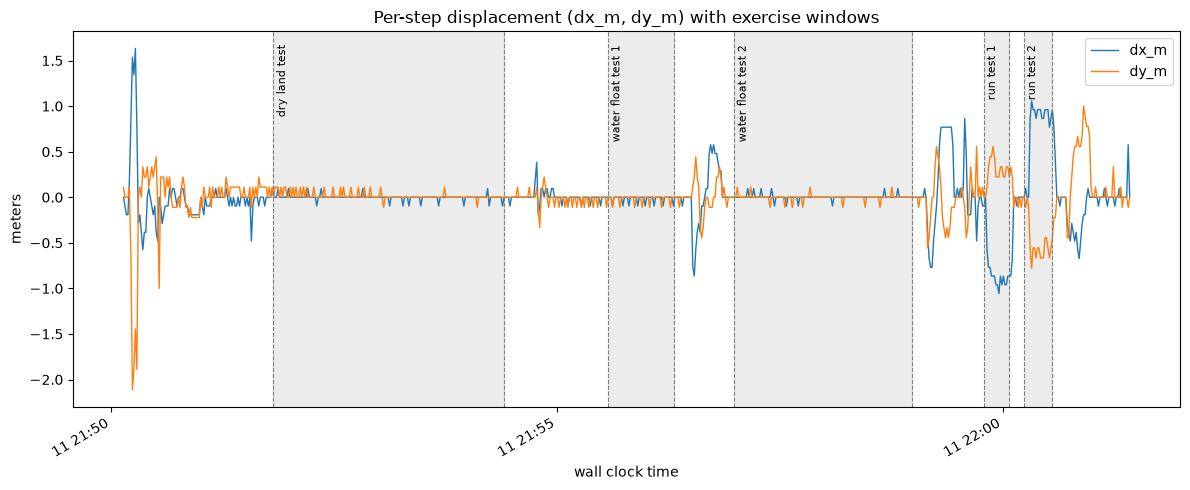

In [ ]:
import json
from datetime import date, datetime

import matplotlib.pyplot as plt

with open("input_data/time_markers.json") as f:
    time_markers = json.load(f)

# The GNSS log's HH:MM:SS.mmm timestamps carry no date either — reuse the
# same date assumed for time_markers.json so both sources share one axis.
log_date = date.fromisoformat(time_markers["metadata"]["log_started_at_wall_clock_time"][:10])
df["datetime"] = df["time"].apply(lambda t: datetime.combine(log_date, t))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["datetime"], df["dx_m"], label="dx_m", linewidth=1)
ax.plot(df["datetime"], df["dy_m"], label="dy_m", linewidth=1)

# Shade each exercise's start-stop window and label it.
for exercise in time_markers["exercises"]:
    start = datetime.fromisoformat(exercise["start"]["wall_clock_time"])
    stop = datetime.fromisoformat(exercise["stop"]["wall_clock_time"])
    ax.axvspan(start, stop, color="gray", alpha=0.15)
    ax.axvline(start, color="gray", linestyle="--", linewidth=0.8)
    ax.axvline(stop, color="gray", linestyle="--", linewidth=0.8)
    ax.annotate(
        exercise["name"],
        xy=(start, ax.get_ylim()[1]),
        xytext=(2, -10),
        textcoords="offset points",
        rotation=90,
        va="top",
        ha="left",
        fontsize=8,
    )

ax.set_xlabel("wall clock time")
ax.set_ylabel("meters")
ax.set_title("Per-step displacement (dx_m, dy_m) with exercise windows")
ax.legend(loc="upper right")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Average speed during run tests

Quick sanity check on boat speed (throttle was approx. 50%, not used in the math) using GNSS positions during `run test 1` and `run test 2` — the two windows where the boat was actually moving under power. The first 10 seconds of each run are trimmed to account for lag in the GNSS fix stream.

We compute average speed two ways: **path-based** (sum of per-step ~1s-interval segments — sensitive to GNSS jitter, which inflates distance regardless of direction) and **displacement-based** (straight-line start→stop distance — immune to that jitter, valid since each run was a straight-line pass).

In [ ]:
from datetime import timedelta

LAG_TRIM = timedelta(seconds=10)

run_names = ["run test 1", "run test 2"]
exercises_by_name = {ex["name"]: ex for ex in time_markers["exercises"]}

for name in run_names:
    exercise = exercises_by_name[name]
    start = datetime.fromisoformat(exercise["start"]["wall_clock_time"]) + LAG_TRIM
    stop = datetime.fromisoformat(exercise["stop"]["wall_clock_time"])

    subset = df[(df["datetime"] >= start) & (df["datetime"] <= stop)]

    duration_s = (subset["datetime"].iloc[-1] - subset["datetime"].iloc[0]).total_seconds()

    # Method 1: sum of per-step (~1s interval) segments. Jitter in each
    # fix adds spurious length regardless of direction, so this tends to
    # overestimate distance on a noisy signal.
    path_distance_m = np.hypot(subset["x_m"].diff(), subset["y_m"].diff()).sum()
    avg_speed_path_mps = path_distance_m / duration_s

    # Method 2: straight-line start→stop displacement. Immune to per-fix
    # jitter, but only accurate if the boat actually travelled in a
    # straight line during the window — true for a run test.
    displacement_m = np.hypot(
        subset["x_m"].iloc[-1] - subset["x_m"].iloc[0],
        subset["y_m"].iloc[-1] - subset["y_m"].iloc[0],
    )
    avg_speed_displacement_mps = displacement_m / duration_s

    print(f"{name}: duration={duration_s:.1f}s, fixes={len(subset)}")
    print(f"  path-based:         {avg_speed_path_mps:.3f} m/s (distance={path_distance_m:.2f} m)")
    print(f"  displacement-based: {avg_speed_displacement_mps:.3f} m/s (distance={displacement_m:.2f} m)")

run test 1: duration=6.0s, fixes=7
  path-based:         0.960 m/s (distance=5.77 m)
  displacement-based: 0.959 m/s (distance=5.76 m)
run test 2: duration=8.0s, fixes=9
  path-based:         1.079 m/s (distance=8.63 m)
  displacement-based: 1.074 m/s (distance=8.59 m)


## GPS position drift while stationary

During `dry land test` the boat wasn't moving at all, so any apparent movement in `x_m`/`y_m` up to that point is pure GPS error, not real motion. By the end of the window the fix has had the most time to settle (most satellites, best HDOP), so we treat the **last** fix as the true position and measure distance from it — using every fix from the very beginning of the log, not just from the marked start of `dry land test`, so we capture the full settling behavior right from GPS acquisition.

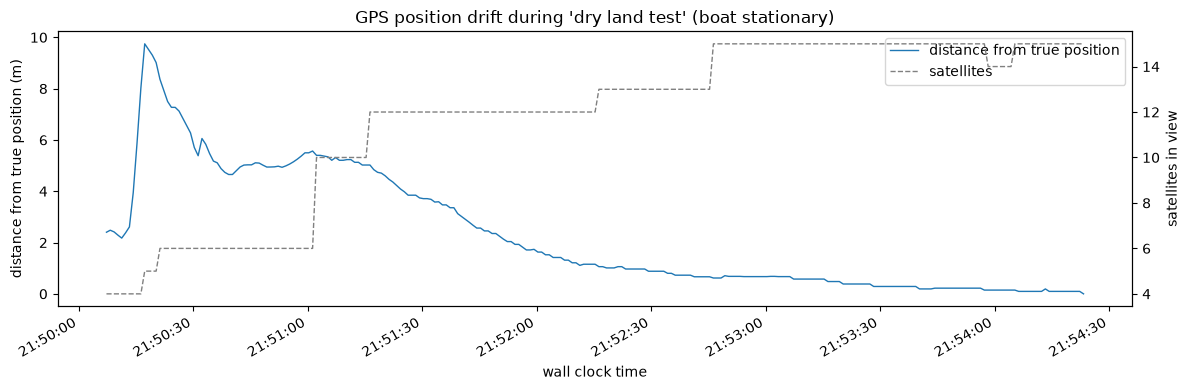

fixes: 257, duration: 256s
max distance from true position:     9.75 m
initial distance from true position: 2.40 m
mean distance from true position:    2.33 m
avg sats / hdop during window: 11.7 / 1.03


In [ ]:
dry_land = exercises_by_name["dry land test"]
stop = datetime.fromisoformat(dry_land["stop"]["wall_clock_time"])

# No start cutoff — use every fix from the very beginning of the log up
# through the end of the stationary 'dry land test' window.
still = df[df["datetime"] <= stop]

# The true position is taken as the *last* fix in the window: by then
# the fix has had the most time to settle (most satellites, best
# HDOP), so every earlier fix is measured as distance from it.
true_x, true_y = still["x_m"].iloc[-1], still["y_m"].iloc[-1]
drift_x_m = still["x_m"] - true_x
drift_y_m = still["y_m"] - true_y
drift_dist_m = np.hypot(drift_x_m, drift_y_m)

fig, ax = plt.subplots(figsize=(12, 4))
line_drift, = ax.plot(still["datetime"], drift_dist_m, linewidth=1, label="distance from true position")
ax.set_xlabel("wall clock time")
ax.set_ylabel("distance from true position (m)")
ax.set_title("GPS position drift during 'dry land test' (boat stationary)")

# Satellite count on its own axis — very different scale/units from drift.
ax2 = ax.twinx()
line_sats, = ax2.plot(still["datetime"], still["sats"], color="gray", linestyle="--", linewidth=1, label="satellites")
ax2.set_ylabel("satellites in view")

ax.legend(handles=[line_drift, line_sats], loc="upper right")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(f"fixes: {len(still)}, duration: {(still['datetime'].iloc[-1] - still['datetime'].iloc[0]).total_seconds():.0f}s")
print(f"max distance from true position:     {drift_dist_m.max():.2f} m")
print(f"initial distance from true position: {drift_dist_m.iloc[0]:.2f} m")
print(f"mean distance from true position:    {drift_dist_m.mean():.2f} m")
print(f"avg sats / hdop during window: {still['sats'].mean():.1f} / {still['hdop'].mean():.2f}")